<a href="https://colab.research.google.com/github/dkumar-tech/desktop-tutorial/blob/main/CSVGenProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Generate Telco OSS Alarms Data

First, let's create a synthetic dataset of telco OSS alarms. This dataset will include various columns relevant to alarm monitoring, such as timestamp, alarm ID, severity, affected component, and a description. We will generate 100 rows of data.

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a seed for reproducibility
np.random.seed(42)

# Number of alarms to generate
num_alarms = 100

# Generate timestamps
start_time = datetime(2023, 10, 1, 8, 0, 0)
end_time = datetime(2023, 10, 3, 18, 0, 0)
time_diff = (end_time - start_time).total_seconds()
timestamps = [start_time + timedelta(seconds=np.random.randint(time_diff)) for _ in range(num_alarms)]

# Generate alarm IDs
alarm_ids = [f'ALARM-{i:05d}' for i in range(1, num_alarms + 1)]

# Generate severity levels
severity_options = ['Critical', 'Major', 'Minor', 'Warning', 'Informational']
severities = np.random.choice(severity_options, num_alarms, p=[0.1, 0.2, 0.3, 0.25, 0.15])

# Generate component types
component_options = ['RAN', 'Core', 'Transport', 'Access', 'Power_Supply', 'Software']
components = np.random.choice(component_options, num_alarms)

# Generate descriptions
description_templates = [
    'Link down on {component} interface',
    'High CPU utilization on {component} server',
    'Memory alarm on {component} unit',
    'Packet loss detected on {component} path',
    'Temperature sensor critical on {component} rack',
    'Software error in {component} module',
    'Power failure in {component} cabinet',
    'Service degradation in {component} region'
]
descriptions = [template.format(component=comp) for template, comp in zip(np.random.choice(description_templates, num_alarms), components)]

# Generate status
status_options = ['Active', 'Cleared']
# More active alarms initially, some cleared randomly
statuses = np.random.choice(status_options, num_alarms, p=[0.7, 0.3])

# Generate duration (in seconds)
durations = np.random.randint(60, 3600, num_alarms) # 1 minute to 1 hour

# Generate categories
category_options = [
    'Network Connectivity',
    'Performance Issue',
    'Hardware Failure',
    'Software Glitch',
    'Environmental',
    'Power Outage'
]
categories = np.random.choice(category_options, num_alarms)

# Generate location details
location_options = ['New York', 'London', 'Tokyo', 'Paris', 'Sydney', 'Mumbai']
locations = np.random.choice(location_options, num_alarms)

# Generate node details
node_options = [f'Node-{i:03d}' for i in range(1, 21)] # 20 different nodes
nodes = np.random.choice(node_options, num_alarms)

# Create DataFrame
alarms_df = pd.DataFrame({
    'timestamp': timestamps,
    'alarm_id': alarm_ids,
    'severity': severities,
    'component': components,
    'description': descriptions,
    'status': statuses,
    'duration_seconds': durations,
    'category': categories,
    'location': locations, # Added location
    'node': nodes          # Added node
})

# Sort by timestamp
alarms_df = alarms_df.sort_values(by='timestamp').reset_index(drop=True)

# Save to CSV
csv_file_path = 'telco_oss_alarms.csv'
alarms_df.to_csv(csv_file_path, index=False)

print(f"Generated {num_alarms} alarms and saved to '{csv_file_path}'")

Generated 100 alarms and saved to 'telco_oss_alarms.csv'


Here are the first 5 rows of the generated alarms data:

In [5]:
display(alarms_df.head())

,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016


### LLM Processing for Root Cause Analysis (RCA)

Now, let's prepare the data for an LLM to perform Root Cause Analysis. We will load the generated CSV file and create a consolidated text field for each alarm, combining relevant information into a single prompt string.

In [7]:
# Load the generated CSV file
alarms_df = pd.read_csv('telco_oss_alarms.csv')

# Display the first few rows to confirm loading
print("Loaded alarms_df:")
display(alarms_df.head())

# Prepare data for LLM by creating a consolidated text field
alarms_df['llm_input_text'] = alarms_df.apply(
    lambda row: f"Alarm ID: {row['alarm_id']}. Timestamp: {row['timestamp']}. Severity: {row['severity']}. Component: {row['component']}. Location: {row['location']}. Node: {row['node']}. Category: {row['category']}. Description: {row['description']}. Status: {row['status']}. Duration: {row['duration_seconds']} seconds.",
    axis=1
)

print("\nFirst 2 LLM input texts generated:")
for i in range(min(2, len(alarms_df))):
    print(f"---\n{alarms_df.loc[i, 'llm_input_text']}\n---")


Loaded alarms_df:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016



First 2 LLM input texts generated:
---
Alarm ID: ALARM-00020. Timestamp: 2023-10-01 08:12:49. Severity: Critical. Component: Core. Location: New York. Node: Node-006. Category: Hardware Failure. Description: Temperature sensor critical on Core rack. Status: Active. Duration: 2203 seconds.
---
---
Alarm ID: ALARM-00091. Timestamp: 2023-10-01 08:16:56. Severity: Informational. Component: Power_Supply. Location: Tokyo. Node: Node-012. Category: Environmental. Description: Service degradation in Power_Supply region. Status: Active. Duration: 1257 seconds.
---


### Placeholder for LLM Integration

Below is a conceptual function `call_llm_for_rca` that mimics an interaction with an LLM for Root Cause Analysis. In a real-world scenario, you would replace this with actual API calls to a chosen LLM (e.g., Google's Gemini API, OpenAI's GPT, etc.).

In [8]:
def call_llm_for_rca(alarm_text):
    """
    Placeholder function to simulate an LLM call for Root Cause Analysis.
    In a real scenario, this would make an API call to an actual LLM.
    """
    # Simulate a brief delay for API call
    # import time
    # time.sleep(0.5)

    # Generate a dummy RCA response based on keywords
    if 'CPU utilization' in alarm_text:
        rca = "High CPU utilization detected. Possible root causes include process overload or misconfigured application. Investigate active processes and resource limits."
    elif 'Memory alarm' in alarm_text:
        rca = "Memory alarm triggered. Likely due to memory leak in a service or excessive memory allocation. Check application logs for memory-related errors and review memory usage."
    elif 'Link down' in alarm_text:
        rca = "Network link down. Could be a physical cable issue, faulty port, or configuration error. Verify physical connectivity and port status."
    elif 'Power failure' in alarm_text:
        rca = "Power failure detected. Check power supply units, circuit breakers, and facility power. Confirm redundant power sources are active."
    elif 'Service degradation' in alarm_text:
        rca = "Service degradation. Could be a cascading failure from another component, network congestion, or application performance issue. Correlate with other alarms and performance metrics."
    else:
        rca = "Generic alarm. Further investigation needed. Check logs and related system metrics for anomalies."

    return f"[Simulated RCA]: {rca}"

# Apply the placeholder LLM function to the 'llm_input_text' column
alarms_df['rca_llm_response'] = alarms_df['llm_input_text'].apply(call_llm_for_rca)

print("First 2 alarms with simulated LLM RCA response:")
for i in range(min(2, len(alarms_df))):
    print(f"---\nAlarm Text: {alarms_df.loc[i, 'llm_input_text']}\nSimulated RCA: {alarms_df.loc[i, 'rca_llm_response']}\n---")

First 2 alarms with simulated LLM RCA response:
---
Alarm Text: Alarm ID: ALARM-00020. Timestamp: 2023-10-01 08:12:49. Severity: Critical. Component: Core. Location: New York. Node: Node-006. Category: Hardware Failure. Description: Temperature sensor critical on Core rack. Status: Active. Duration: 2203 seconds.
Simulated RCA: [Simulated RCA]: Generic alarm. Further investigation needed. Check logs and related system metrics for anomalies.
---
---
Alarm Text: Alarm ID: ALARM-00091. Timestamp: 2023-10-01 08:16:56. Severity: Informational. Component: Power_Supply. Location: Tokyo. Node: Node-012. Category: Environmental. Description: Service degradation in Power_Supply region. Status: Active. Duration: 1257 seconds.
Simulated RCA: [Simulated RCA]: Service degradation. Could be a cascading failure from another component, network congestion, or application performance issue. Correlate with other alarms and performance metrics.
---


### Alarm Visualization and Dashboard

Now, let's visualize the alarm data to understand its distribution, trends, and categories. We will use `matplotlib` and `seaborn` to create several dashboard-like plots.

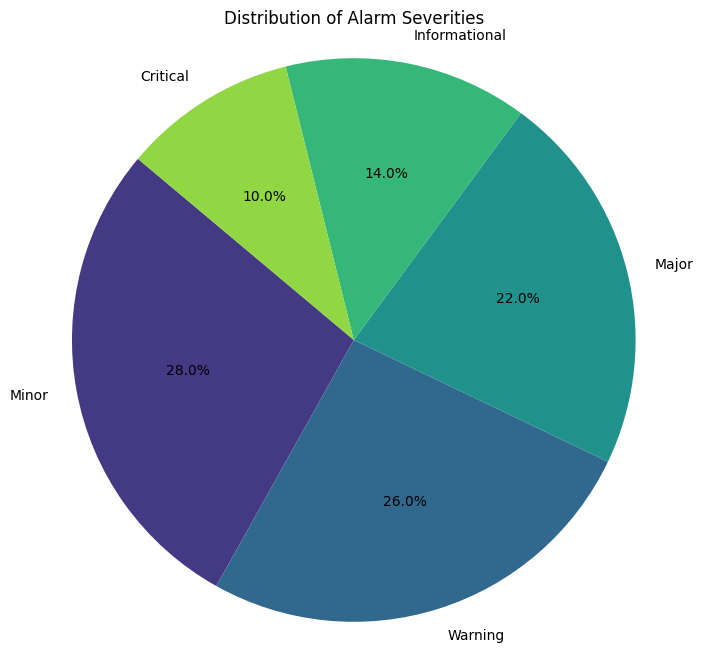

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 1. Alarm Severity Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
severity_counts = alarms_df['severity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(severity_counts)))
plt.title('Distribution of Alarm Severities')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This pie chart shows the percentage distribution of different alarm severity levels, giving you an immediate overview of how critical your alarms are.

/tmp/ipykernel_9782/1151564689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='component', data=alarms_df, order=alarms_df['component'].value_counts().index, palette='magma')


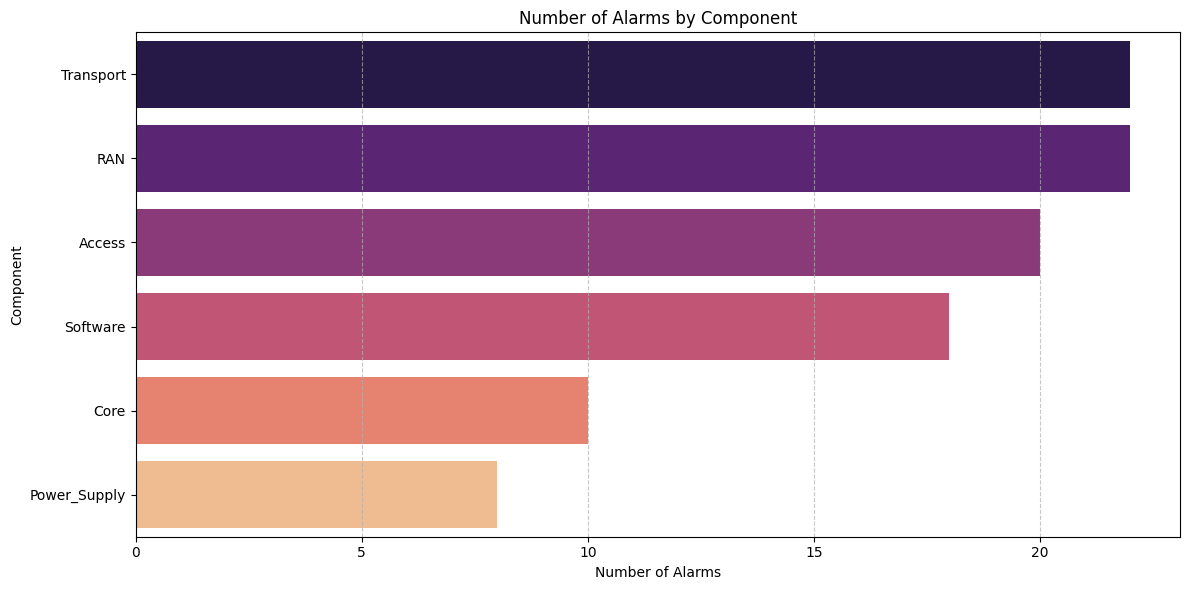

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (if not already done)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 2. Alarms by Component (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(y='component', data=alarms_df, order=alarms_df['component'].value_counts().index, palette='magma')
plt.title('Number of Alarms by Component')
plt.xlabel('Number of Alarms')
plt.ylabel('Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart highlights which network components are experiencing the most alarms, helping to identify problematic areas at a glance.

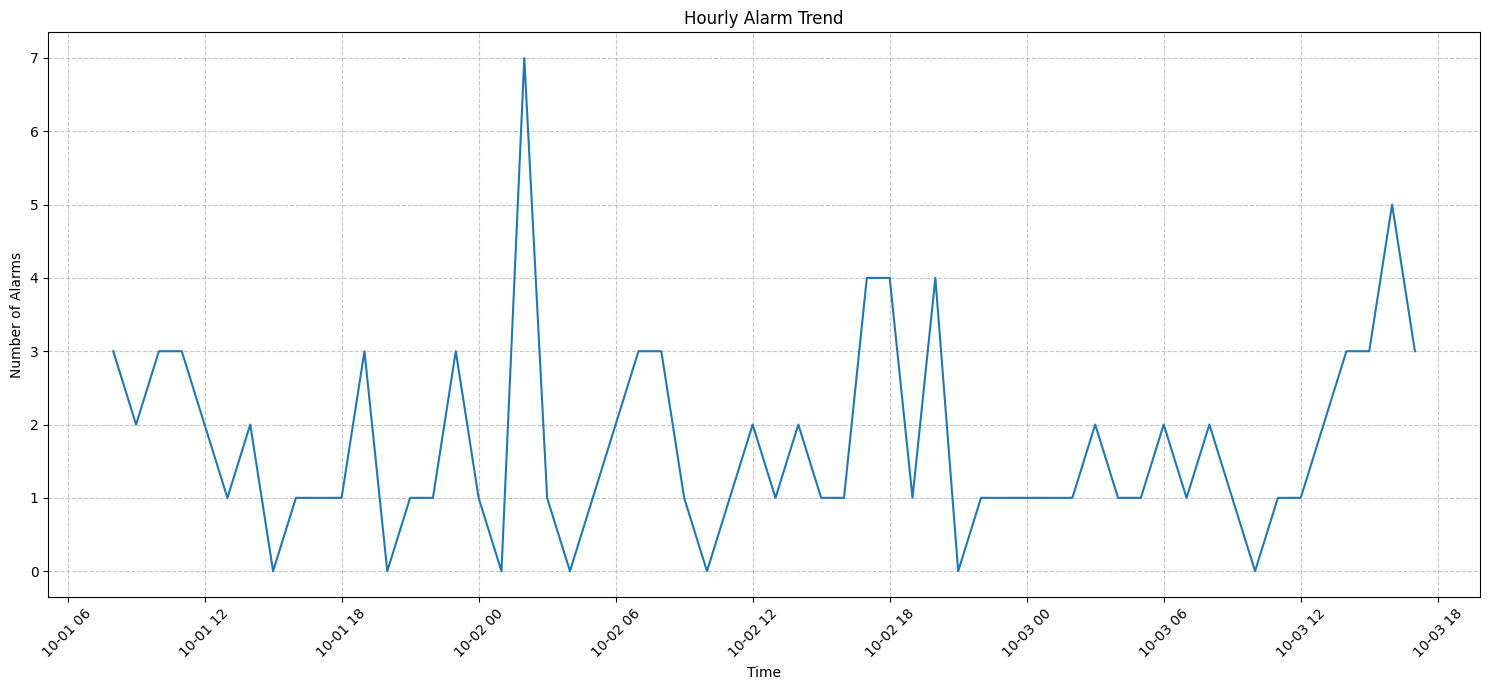

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (important for resampling)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 3. Alarms Over Time (Line Plot - Hourly Trend)
# Resample to hourly counts
hourly_alarms = alarms_df.set_index('timestamp').resample('h').size().reset_index(name='alarm_count') # Changed 'H' to 'h'

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='alarm_count', data=hourly_alarms)
plt.title('Hourly Alarm Trend')
plt.xlabel('Time')
plt.ylabel('Number of Alarms')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This line plot shows the hourly trend of alarms, allowing you to observe patterns, spikes, or quiet periods in your network's activity.

/tmp/ipykernel_9782/2881517260.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=alarms_df, order=alarms_df['category'].value_counts().index, palette='plasma')


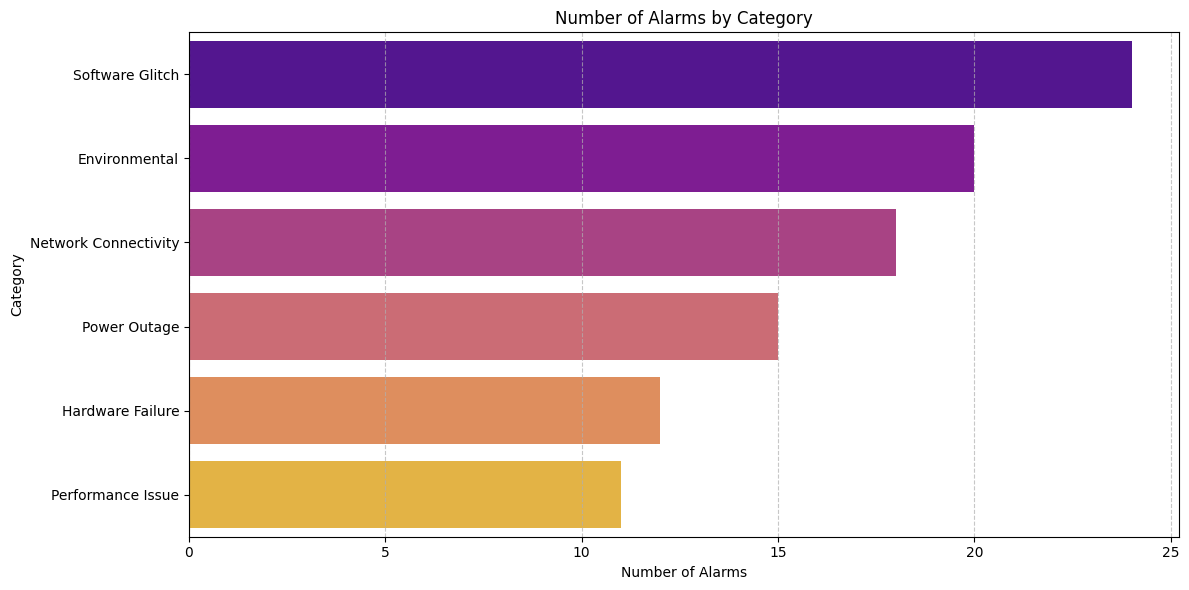

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (if not already done)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 4. Alarms by Category (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=alarms_df, order=alarms_df['category'].value_counts().index, palette='plasma')
plt.title('Number of Alarms by Category')
plt.xlabel('Number of Alarms')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart provides an overview of alarm categories, helping you understand the types of issues most prevalent in your system (e.g., network connectivity, hardware failure, performance issues).